# Random Forest

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    print_classification_report, compute_f1_scores, run_stratified_cv, print_error_patterns,
    plot_f1_bar, plot_confusion_matrices, plot_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

# No clipping or scaling — tree ensembles split on raw thresholds.
X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=StandardScaler(),
    smote_variant="standard",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    300
1.0    200
2.0    200
Name: count, dtype: int64
Balanced train shape: (700, 17)
Class weights: {np.int64(0): np.float64(0.7777777777777778), np.int64(1): np.float64(1.1666666666666667), np.int64(2): np.float64(1.1666666666666667)}

Outputs ready for modeling:
  X_train_bal       → (700, 17) (balanced, scaled)
  y_train_bal       → 700 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
# Stage 1: find n_estimators via OOB convergence
_probe = RandomForestClassifier(
    n_estimators=1, max_features="sqrt", min_samples_leaf=1,
    class_weight=class_weight_dict,
    oob_score=True, warm_start=True,
    random_state=42, n_jobs=-1,
)
_n_range = list(range(10, 801, 10))
_oob_errors = []
for n in _n_range:
    _probe.n_estimators = n
    _probe.fit(X_train_bal, y_train_bal)
    _oob_errors.append(1 - _probe.oob_score_)

_oob_arr = np.array(_oob_errors)
_total_drop = _oob_arr[0] - _oob_arr.min()
_cum_frac = (_oob_arr[0] - _oob_arr) / _total_drop if _total_drop > 0 else np.ones(len(_oob_arr))
_stable = np.where(_cum_frac >= 0.95)[0]
n_estimators_opt = _n_range[_stable[0]] if len(_stable) else _n_range[-1]

print(f"OOB stabilises at n_estimators = {n_estimators_opt}")

# Stage 2: grid search over structural hyperparams
param_grid = {
    "max_features": ["sqrt", "log2"],
    "min_samples_leaf": [1, 2, 4, 8],
}

grid_rf = run_grid_search(
    RandomForestClassifier(
        n_estimators=n_estimators_opt,
        class_weight=class_weight_dict,
        random_state=42, n_jobs=-1,
    ),
    param_grid,
    X_train_bal,
    y_train_bal,
)
rf = grid_rf.best_estimator_

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf  = rf.predict_proba(X_test_scaled)

print(f"Best max_features:     {grid_rf.best_params_['max_features']}")
print(f"Best min_samples_leaf: {grid_rf.best_params_['min_samples_leaf']}")
print(f"Best CV F1 Macro:      {grid_rf.best_score_:.4f}")
print(f"n_estimators:          {rf.n_estimators}  (OOB-optimal)")

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


OOB stabilises at n_estimators = 610
Best max_features:     sqrt
Best min_samples_leaf: 1
Best CV F1 Macro:      0.9901
n_estimators:          610  (OOB-optimal)


## Modeling
### DIAGNOSTIC PLOT 1: Feature Importances (Mean Decrease in Impurity ± Std)

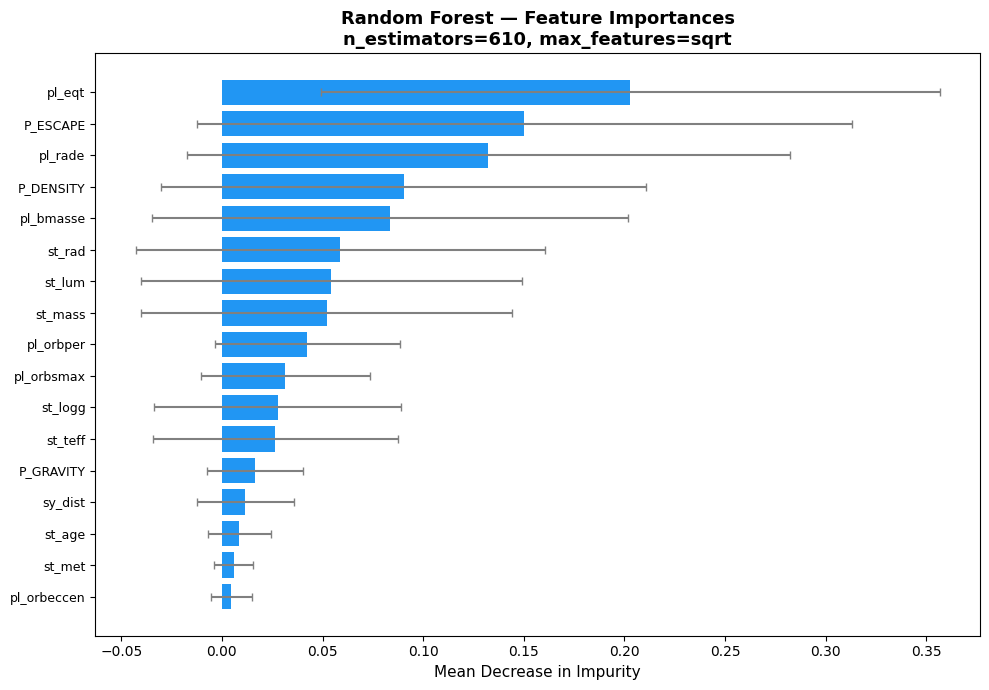

↑ Error bars = std of importance across all trees in the ensemble.
  Wide bars = unstable ranking — the feature's importance varies by which samples each tree saw.
  Compare to DT importances: RF averages over 500 trees, DT reflects a single greedy path.


In [4]:
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    range(len(FEATURES)),
    importances[sorted_idx],
    xerr=std[sorted_idx],
    color="#2196F3", ecolor="gray", capsize=3, edgecolor="none",
)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels([FEATURES[i] for i in sorted_idx], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Mean Decrease in Impurity", fontsize=11)
ax.set_title(
    f"Random Forest — Feature Importances\n"
    f"n_estimators={rf.n_estimators}, max_features={rf.max_features}",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
save_plot("rf_feature_importances")
plt.show()

print("↑ Error bars = std of importance across all trees in the ensemble.")
print("  Wide bars = unstable ranking — the feature's importance varies by which samples each tree saw.")
print("  Compare to DT importances: RF averages over 500 trees, DT reflects a single greedy path.")

### DIAGNOSTIC PLOT 2: min_samples_leaf vs CV F1 Macro

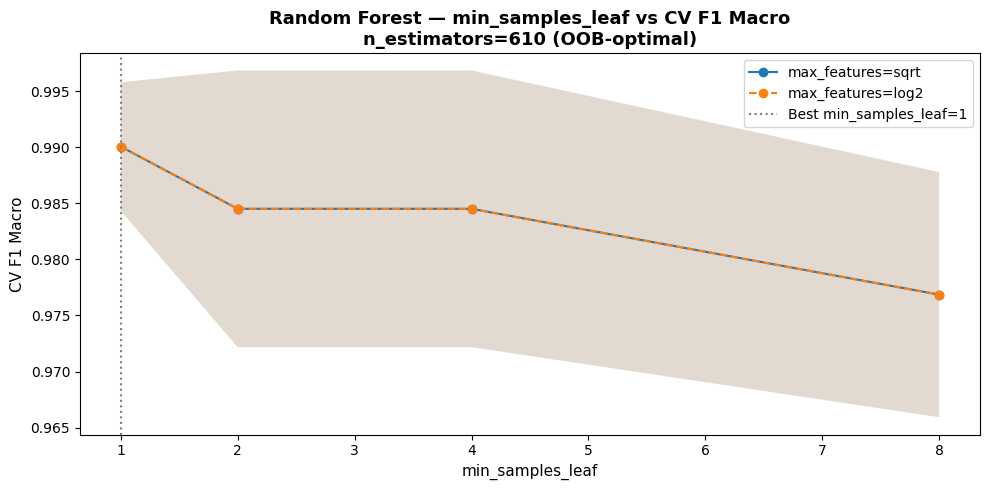

↑ Higher min_samples_leaf = stronger regularisation (leaves must contain more samples to split).
  On a small balanced set, this is the primary guard against overfitting to minority classes.
  Shaded band = ±1 std across CV folds.


In [5]:
results_df = pd.DataFrame(grid_rf.cv_results_)

fig, ax = plt.subplots(figsize=(10, 5))
for mf, ls in [("sqrt", "-"), ("log2", "--")]:
    sub = results_df[results_df["param_max_features"] == mf].sort_values("param_min_samples_leaf")
    ax.plot(sub["param_min_samples_leaf"], sub["mean_test_score"],
            marker="o", ls=ls, label=f"max_features={mf}")
    ax.fill_between(
        sub["param_min_samples_leaf"],
        sub["mean_test_score"] - sub["std_test_score"],
        sub["mean_test_score"] + sub["std_test_score"],
        alpha=0.15,
    )

ax.axvline(grid_rf.best_params_["min_samples_leaf"], color="gray", ls=":", lw=1.5,
           label=f"Best min_samples_leaf={grid_rf.best_params_['min_samples_leaf']}")
ax.set_xlabel("min_samples_leaf", fontsize=11)
ax.set_ylabel("CV F1 Macro", fontsize=11)
ax.set_title(
    f"Random Forest — min_samples_leaf vs CV F1 Macro\n"
    f"n_estimators={rf.n_estimators} (OOB-optimal)",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("rf_min_samples_leaf_sensitivity")
plt.show()

print("↑ Higher min_samples_leaf = stronger regularisation (leaves must contain more samples to split).")
print("  On a small balanced set, this is the primary guard against overfitting to minority classes.")
print("  Shaded band = ±1 std across CV folds.")

### DIAGNOSTIC PLOT 3: OOB Error Convergence

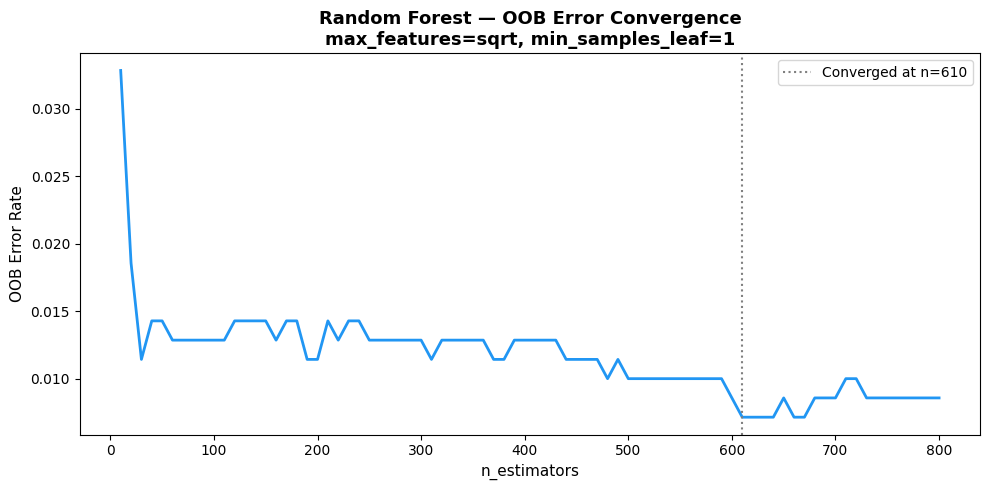

↑ OOB error = each tree evaluated on the ~37% of training samples it never saw.
  Vertical line = where per-step improvement dropped below 2% of its peak rate.
  Using this n_estimators in the final model avoids over- or under-building the ensemble.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(_n_range, _oob_errors, color="#2196F3", lw=2)
ax.axvline(n_estimators_opt, color="gray", ls=":", lw=1.5,
           label=f"Converged at n={n_estimators_opt}")
ax.set_xlabel("n_estimators", fontsize=11)
ax.set_ylabel("OOB Error Rate", fontsize=11)
ax.set_title(
    f"Random Forest — OOB Error Convergence\n"
    f"max_features={rf.max_features}, min_samples_leaf={rf.min_samples_leaf}",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("rf_oob_convergence")
plt.show()

print("↑ OOB error = each tree evaluated on the ~37% of training samples it never saw.")
print("  Vertical line = where per-step improvement dropped below 2% of its peak rate.")
print("  Using this n_estimators in the final model avoids over- or under-building the ensemble.")

## Metrics
### Classification Report + F1 Scores

RF — Classification Report
               precision    recall  f1-score   support

Non-Habitable     0.9991    0.9873    0.9931      1100
   Mesoplanet     0.6000    1.0000    0.7500         6
Psychroplanet     0.3529    0.7500    0.4800         8

     accuracy                         0.9856      1114
    macro avg     0.6507    0.9124    0.7410      1114
 weighted avg     0.9923    0.9856    0.9881      1114

F1 Macro:    0.7410
F1 Weighted: 0.9881

5-Fold CV F1 Macro: 0.9895 ± 0.0111
F1 Macro:    0.7410
F1 Weighted: 0.9881


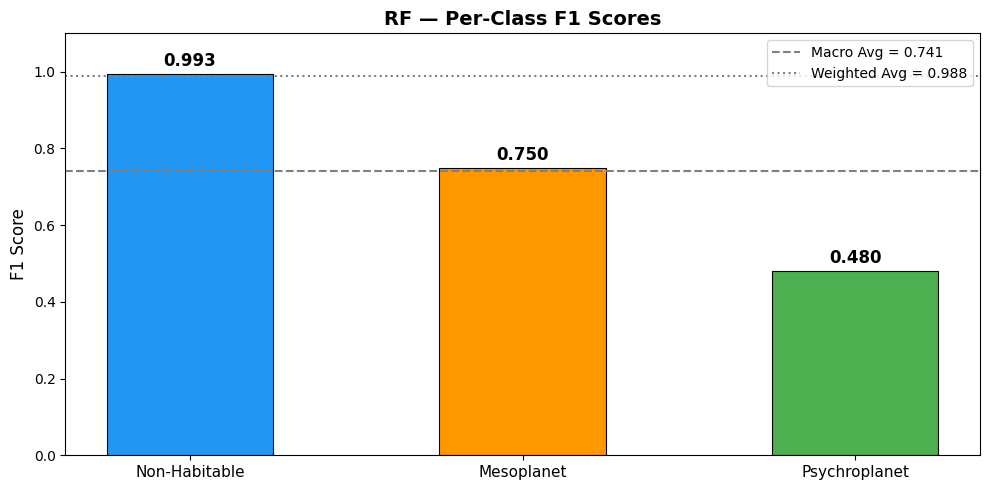

In [7]:
print_classification_report(y_test, y_pred_rf, "RF")

f1_macro_rf, f1_weighted_rf, _ = compute_f1_scores(y_test, y_pred_rf)

cv_scores_rf = run_stratified_cv(rf, X_train_bal, y_train_bal)

plot_f1_bar(y_test, y_pred_rf, "RF")

### Confusion Matrices (Counts + Normalized)

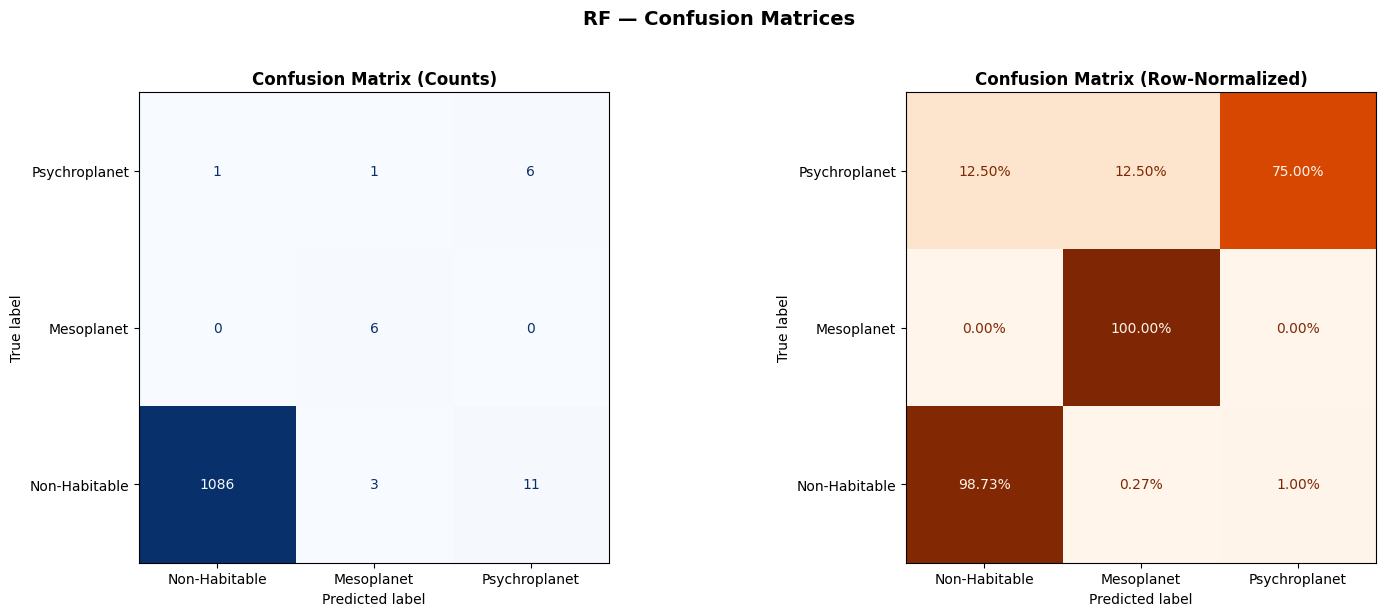

Key error patterns:
  Non-Habitable → predicted Mesoplanet: 3 (0.3% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 11 (1.0% of true Non-Habitable)
  Psychroplanet → predicted Non-Habitable: 1 (12.5% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 1 (12.5% of true Psychroplanet)


In [8]:
plot_confusion_matrices(y_test, y_pred_rf, "RF")
print_error_patterns(y_test, y_pred_rf)

## Interpretation: